# Classification by Chord Changes
Loads a `.wav` file, splits it into 5 consecutive 2-second chunks, and plots a Constant Q-Transform (CQT) spectrogram for each chunk.

In [19]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import song_analysis_utils

%matplotlib inline

In [ ]:
import pandas as pd

CSV_V2 = "../gtzan/GTZAN_Enriched_V2.csv"

df = pd.read_csv(CSV_V2)
print(f"Updated {CSV_V2}")
df[["File Name", "GT Key", "Key Name"]].head(10)

In [21]:
from song_analysis_utils import (
    KeyEstimator,
    circle_of_fifths,
    get_romanized_chords,
    get_chromagram,
    get_best_romanized_chords,
    chord_change_matrix,
    analyze_song,
    analyze_all_songs,
    get_steady_state,
    steady_state_vec,
    pcca_plus,
)

In [ ]:
# --- Configuration ---
WAV_FILE = "../gtzan/Data/genres_original/blues/blues.00039.wav"  # <-- change this to your .wav file path
CHUNK_DURATION = 2          # seconds per chunk
NUM_CHUNKS = 5
HOP_LENGTH = 512

In [49]:
# Load audio
y, sr = librosa.load(WAV_FILE, sr=None, mono=True)
print(f"Sample rate : {sr} Hz")
print(f"Duration    : {len(y) / sr:.2f}s")

Sample rate : 22050 Hz
Duration    : 30.01s


In [5]:
# Split into chunks
chunk_samples = int(CHUNK_DURATION * sr)
required = chunk_samples * NUM_CHUNKS

if len(y) < required:
    raise ValueError(
        f"Audio too short: need at least {NUM_CHUNKS * CHUNK_DURATION:.0f}s, "
        f"got {len(y) / sr:.2f}s."
    )

chunks = [y[i * chunk_samples : (i + 1) * chunk_samples] for i in range(NUM_CHUNKS)]
print(f"Split into {len(chunks)} chunks of {CHUNK_DURATION:.2f}s each.")

Split into 5 chunks of 2.00s each.


In [ ]:
# Compute and plot CQT spectrogram for each chunk
fig, axes = plt.subplots(NUM_CHUNKS, 1, figsize=(10, 4 * NUM_CHUNKS))

for i, (chunk, ax) in enumerate(zip(chunks, axes)):
    C = librosa.cqt(chunk, sr=sr, hop_length=HOP_LENGTH)
    C_db = librosa.amplitude_to_db(np.abs(C), ref=np.max)

    img = librosa.display.specshow(
        C_db,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="cqt_hz",
        ax=ax,
    )
    fig.colorbar(img, ax=ax, format="%+2.0f dB")
    ax.set_title(f"CQT Spectrogram — Chunk {i + 1} ({i * CHUNK_DURATION:.2f}–{(i + 1) * CHUNK_DURATION:.2f}s)")

plt.tight_layout()
plt.show()

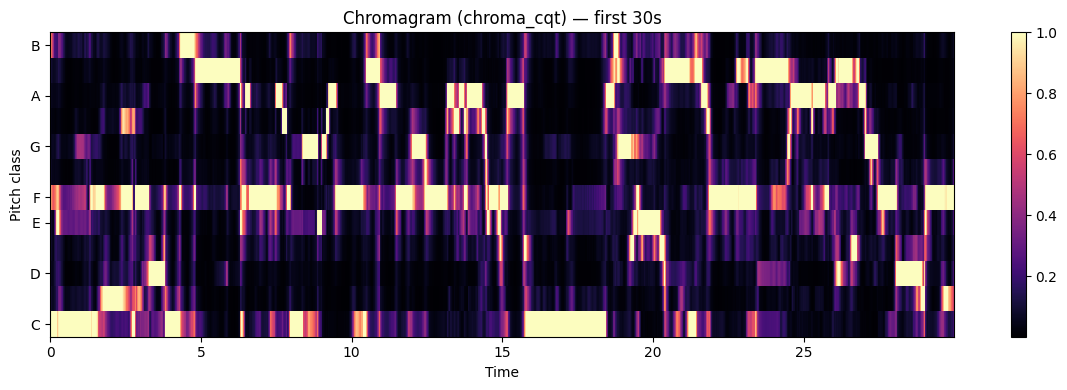

In [60]:
# Chromagram (chroma_cqt) — first 30 seconds
CHROMA_DURATION = 30  # seconds

y, sr = librosa.load(WAV_FILE, sr=None, mono=True, duration=CHROMA_DURATION)

y_harmonic, y_percussive = librosa.effects.hpss(y)

def get_chromagram(y, sr):
    chroma = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=HOP_LENGTH)

    fig, ax = plt.subplots(figsize=(12, 4))
    img = librosa.display.specshow(
        chroma,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="chroma",
        ax=ax,
    )
    fig.colorbar(img, ax=ax)
    ax.set_title(f"Chromagram (chroma_cqt) — first {CHROMA_DURATION}s")
    plt.tight_layout()
    plt.show()

    return chroma

chroma = get_chromagram(y_harmonic, sr)

In [61]:

PITCH_CLASSES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
WINDOW_DURATION = 0.5  # seconds

frame_duration = HOP_LENGTH / sr
window_frames = max(1, int(WINDOW_DURATION / frame_duration))
n_frames = chroma.shape[1]

# Build 0.5s windows and get top-3 pitches (ordered by energy, descending)
windows = []
for start_f in range(0, n_frames, window_frames):
    end_f = min(start_f + window_frames, n_frames)
    mean_energy = chroma[:, start_f:end_f].mean(axis=1)
    top3 = tuple(np.argsort(mean_energy)[::-1][:3])
    t_start = start_f * frame_duration
    t_end = end_f * frame_duration
    windows.append((top3, t_start, t_end))

# Print only on changes
print("Top-3 dominant pitches per 0.5s window (shown on change):\n")
print(f"{'Start':>8}  {'End':>8}  Notes")
print("-" * 38)

prev_top3 = None
for top3, t_start, t_end in windows:
    if top3 != prev_top3:
        notes = '  '.join(PITCH_CLASSES[i] for i in top3)
        print(f"{t_start:>7.2f}s  {t_end:>7.2f}s  {notes}")
        prev_top3 = top3


Top-3 dominant pitches per 0.5s window (shown on change):

   Start       End  Notes
--------------------------------------
   0.00s     0.49s  C  F  E
   0.98s     1.46s  C  F  G
   1.46s     1.95s  F  C#  C
   1.95s     2.44s  C#  F  G#
   2.44s     2.93s  F  G#  C#
   2.93s     3.41s  F  D  C#
   3.41s     3.90s  D  C  F
   3.90s     4.39s  C  F  B
   4.39s     4.88s  B  C  F
   4.88s     5.36s  A#  B  F
   5.85s     6.34s  A#  A  F
   6.34s     6.83s  F  A  E
   6.83s     7.31s  F  E  C
   7.31s     7.80s  F  A  C
   7.80s     8.29s  C  F  B
   8.29s     8.78s  G  C  E
   8.78s     9.26s  G  E  G#
   9.26s     9.75s  F  A  E
   9.75s    10.24s  F  C  F#
  10.24s    10.73s  F  C  A#
  10.73s    11.22s  A  A#  F
  11.22s    11.70s  A  F  E
  11.70s    12.19s  F  G  C
  12.19s    12.68s  F  G  F#
  12.68s    13.17s  F  F#  E
  13.17s    13.65s  A  G#  F
  13.65s    14.14s  A  F  G#
  14.14s    14.63s  G#  F  A
  14.63s    15.12s  F  E  D#
  15.12s    15.60s  A  G#  F
  15.60s    16.09

In [62]:
# Extract chords from WAV_FILE using chord-extractor (Chordino)
from chord_extractor.extractors import Chordino

chordino = Chordino(roll_on=1)
chords = chordino.extract(WAV_FILE)

print(f"{'Timestamp':>10}  Chord")
print("-" * 22)
for c in chords:
    print(f"{c.timestamp:>9.2f}s  {c.chord}")

 Timestamp  Chord
----------------------
     0.37s  N
     0.46s  Fm
     4.83s  Bb
     6.41s  F
     8.08s  C
     9.29s  F
    15.88s  C
    20.25s  Cm7
    21.64s  F
    22.66s  Bbmaj7
    24.80s  Dm
    28.98s  F
    30.37s  N


Parsing rules:
'N' -> removed from list,
'$' or '$b' where $ is a capital letter -> capitalized roman numeral,
'$maj' -> treat the same as '$',
'$m' where * is a capital letter -> lowercase roman numeral,
'$aug' -> treat the same as '$',
'$/%' where % is one capital letter and % is a different capital letter -> treat the same as '$'
'#n' where # is any of the above expression and n is a digit 1-9 -> treat the same as '#' and then add the number 'n' to the end of the resulting roman numeral


## Key Determination

In [10]:
# Taken from: https://gist.github.com/bmcfee/1f66825cef2eb34c839b42dddbad49fd

import scipy.linalg
from scipy.stats import zscore

from dataclasses import dataclass
from typing import List


@dataclass
class KeyEstimator:

    # adapted from:
    # https://gist.github.com/bmcfee/1f66825cef2eb34c839b42dddbad49fd

    # Coefficients from Kumhansl and Schmuckler
    # as reported here: http://rnhart.net/articles/key-finding/
    major = np.asarray(
        [6.35, 2.23, 3.48, 2.33, 4.38, 4.09, 2.52, 5.19, 2.39, 3.66, 2.29, 2.88]
    )
    minor = np.asarray(
        [6.33, 2.68, 3.52, 5.38, 2.60, 3.53, 2.54, 4.75, 3.98, 2.69, 3.34, 3.17]
    )

    def __post_init__(self):
        self.major = zscore(self.major)
        self.major_norm = scipy.linalg.norm(self.major)
        self.major = scipy.linalg.circulant(self.major)

        self.minor = zscore(self.minor)
        self.minor_norm = scipy.linalg.norm(self.minor)
        self.minor = scipy.linalg.circulant(self.minor)

    def __call__(self, x: np.array) -> tuple[np.array, np.array]:

        x = zscore(x)
        x_norm = scipy.linalg.norm(x)

        coeffs_major = self.major.T.dot(x) / self.major_norm / x_norm
        coeffs_minor = self.minor.T.dot(x) / self.minor_norm / x_norm

        return coeffs_major, coeffs_minor

In [63]:
# Compute the Chroma Short-Time Fourier Transform (chroma_stft)
chromagram = librosa.feature.chroma_stft(y=y_harmonic, sr=sr, hop_length=HOP_LENGTH)

# Calculate the mean chroma feature across time
mean_chroma = np.mean(chromagram, axis=1)

key_predictions = KeyEstimator()(mean_chroma)

keys = ['C Major', 'Db Major', 'D Major', 'Eb Major', 'E Major', 'F Major', 'Gb Major', 'G Major', 'Ab Major', 'A Major', 'Bb Major', 'B Major', # major keys
        'C Minor', 'Db Minor', 'D Minor', 'Eb Minor', 'E Minor', 'F Minor', 'Gb Minor', 'G Minor', 'Ab Minor', 'A Minor', 'Bb Minor', 'B Minor']  # minor keys

key_predictions = np.concatenate([key_predictions[0], key_predictions[1]])  # Combine major and minor predictions
print(key_predictions)
predicted_key_index = np.argmax(key_predictions)

predicted_key = keys[predicted_key_index]
print(f"Predicted key: {predicted_key}")

[ 0.29079975  0.06002518 -0.31208956 -0.23902967 -0.0660497   0.7718978
 -0.08370468 -0.35150271 -0.15739658 -0.04044377  0.30647654 -0.17898261
 -0.13475269 -0.17385359  0.32779124 -0.17924573 -0.1356357   0.51579796
 -0.03607266 -0.2872974  -0.38060532  0.41420205  0.35670972 -0.28703788]
Predicted key: F Major


In [200]:
romanized_chords, final_predicted_key = get_best_romanized_chords(predicted_key, chords)

Key selected: B Major  (* counts: {'B Major': 1, 'Gb Major': 2, 'E Major': 1, 'Ab Minor': 1, 'B Minor': 1})


- For songs which are NOT minor, not in classical/disco/blues, use manually-labeled key

In [66]:
def get_chromagram(y, sr, duration):
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=HOP_LENGTH)

    fig, ax = plt.subplots(figsize=(12, 4))
    img = librosa.display.specshow(
        chroma,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="chroma",
        ax=ax,
    )
    fig.colorbar(img, ax=ax)
    ax.set_title(f"Chromagram (chroma_stft) — first {duration}s")
    plt.tight_layout()
    plt.show()

    return chroma

In [67]:
def analyze_song(wav_file: str, duration = 30) -> tuple[str, str, np.ndarray]:
    """
    Full pipeline:
      1. Load audio and apply HPSS
      2. Extract chords with Chordino
      3. Predict key with KeyEstimator
      4. Romanize chords, switching key to minimize out-of-key chords
      5. Compute and return the mode, final key, and chord-change transition matrix

    Returns: (mode: str, final_key: str, matrix: np.ndarray)
    """
    sharp_to_flat = {'C#': 'Db', 'D#': 'Eb', 'E#': 'F', 'F#': 'Gb',
                     'G#': 'Ab', 'A#': 'Bb', 'B#': 'C'}

    def normalize_chord(chord_str):
        if len(chord_str) > 1 and chord_str[1] == '#':
            return sharp_to_flat[chord_str[:2]] + chord_str[2:]
        return chord_str

    y, sr = librosa.load(wav_file, sr=None, mono=True, duration=duration)
    y_harmonic, _ = librosa.effects.hpss(y)

    chordino  = Chordino(roll_on=1)
    raw_chords = chordino.extract(wav_file, duration = duration)
    chords     = [c._replace(chord=normalize_chord(c.chord)) for c in raw_chords]

    chromagram = get_chromagram(y_harmonic, sr, duration)
    mean_chroma = np.mean(chromagram, axis=1)
    coeffs_major, coeffs_minor = KeyEstimator()(mean_chroma)

    pitch_classes = ['C', 'Db', 'D', 'Eb', 'E', 'F', 'Gb', 'G', 'Ab', 'A', 'Bb', 'B']
    all_coeffs  = np.concatenate([coeffs_major, coeffs_minor])
    best_idx    = np.argmax(all_coeffs)
    predicted_key = (f"{pitch_classes[best_idx % 12]} Major"
                     if best_idx < 12 else
                     f"{pitch_classes[best_idx % 12]} Minor")
    print(f"Predicted key: {predicted_key}")

    romanized, final_key = get_best_romanized_chords(predicted_key, chords)
    print(f"Chords (raw):   {[c.chord for c in chords if c.chord != 'N']}")
    print(f"Chord sequence: {romanized}")

    mode = "Major" if final_key.endswith(" Major") else "Minor"
    
    return mode, final_key, chord_change_matrix(final_key, romanized)

In [ ]:
mode, key, markov_matrix = analyze_song("../gtzan/Data/genres_original/classical/classical.00079.wav", 30)
#mode, key, markov_matrix = analyze_song("../Semi-Charmed Life.flac", 15)

if mode == "Major":
    labels = ['I', 'ii', 'iii', 'IV', 'V', 'vi', 'vii°', '*']
else:
    labels = ['i', 'ii°', 'III', 'iv', 'v', 'VI', 'VII', '*']

plt.imshow(markov_matrix, cmap='Blues')
plt.colorbar()
plt.title("Chord-Change Transition Matrix")
plt.xlabel("Next Chord")
plt.ylabel("Current Chord")
plt.yticks(ticks=np.arange(8), labels=labels)
plt.xticks(ticks=np.arange(8), labels=labels)

In [37]:
get_steady_state(markov_matrix)

array([0.33333333, 0.        , 0.        , 0.33333333, 0.33333333,
       0.        , 0.        , 0.        ])

In [ ]:
import glob
import os

def analyze_all_songs(root_dir: str) -> dict:
    """
    Run analyze_song on every .wav file under root_dir and store results in a
    nested dictionary keyed by mode, then by song title.

    Returns:
        {
            "Major": { "song_title": {"matrix": np.ndarray, "key": str}, ... },
            "Minor": { "song_title": {"matrix": np.ndarray, "key": str}, ... },
        }
    """
    wav_files = glob.glob(f"{root_dir}/**/*.wav", recursive=True)
    print(f"Found {len(wav_files)} .wav files\n")

    results = {"Major": {}, "Minor": {}}

    for i, wav_file in enumerate(wav_files):
        title = os.path.splitext(os.path.basename(wav_file))[0]
        print(f"[{i+1}/{len(wav_files)}] {title}")
        try:
            mode, key, matrix = analyze_song(wav_file)
            if matrix.sum() == 0:
                print("  SKIPPED: <= 1 chord detected, no transitions to record.")
                continue
            results[mode][title] = {"matrix": matrix, "key": key}
        except Exception as e:
            print(f"  ERROR: {e}")
        print()

    return results

markov_matrices = analyze_all_songs("../gtzan/Data/genres_original")

In [36]:
def get_steady_state(matrix: np.ndarray) -> np.ndarray:
    """
    Compute the steady-state distribution of a row-stochastic Markov matrix.
    Finds the left eigenvector of P corresponding to eigenvalue 1,
    i.e. the right eigenvector of P^T with eigenvalue 1.
    """
    eigenvalues, eigenvectors = np.linalg.eig(matrix.T)
    idx = np.argmin(np.abs(eigenvalues - 1))
    steady_state = eigenvectors[:, idx].real
    steady_state = np.abs(steady_state)
    return steady_state / steady_state.sum()

major_songs   = markov_matrices["Major"]
major_titles  = list(major_songs.keys())
major_steady_states = np.array([
    get_steady_state(major_songs[t]["matrix"]) for t in major_titles
])
print(f"Steady-state vectors shape: {major_steady_states.shape}")

NameError: name 'markov_matrices' is not defined

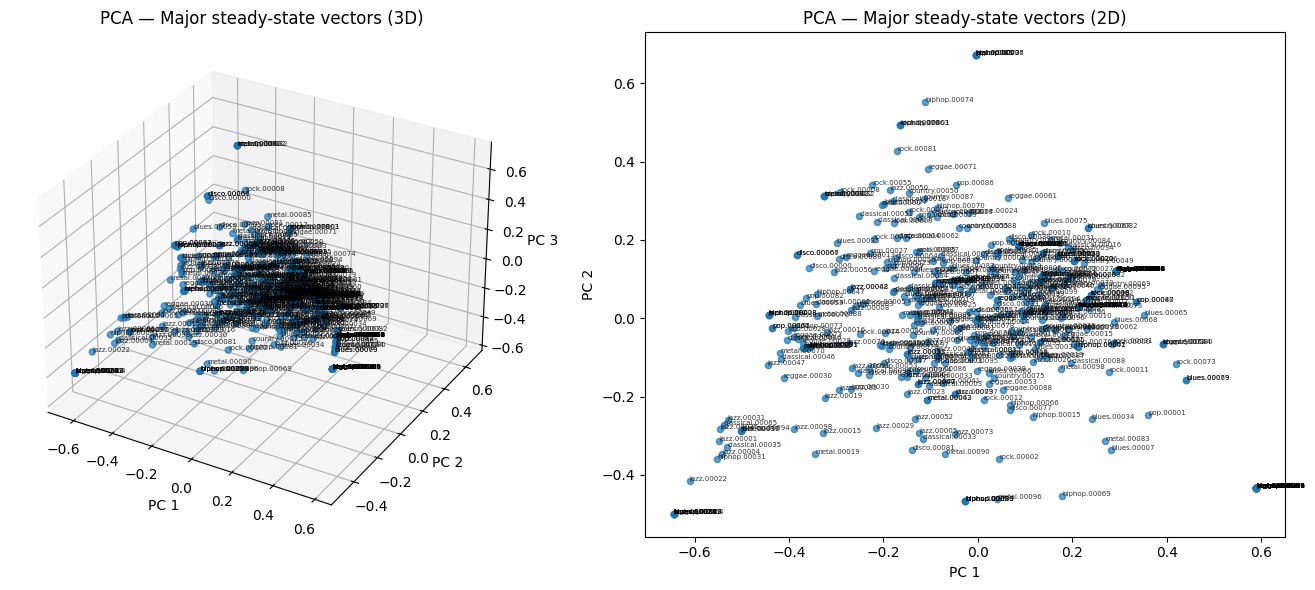

In [102]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# --- Dimensionality reduction ---
pca_3d_coords = PCA(n_components=3).fit_transform(major_steady_states)
pca_2d_coords = PCA(n_components=2).fit_transform(major_steady_states)

# --- Plot ---
fig = plt.figure(figsize=(14, 6))

# 3D PCA
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(pca_3d_coords[:, 0], pca_3d_coords[:, 1], pca_3d_coords[:, 2], s=20, alpha=0.7)
for i, song_title in enumerate(major_titles):
    ax1.text(pca_3d_coords[i, 0], pca_3d_coords[i, 1], pca_3d_coords[i, 2],
             song_title, fontsize=5, alpha=0.8)
ax1.set_title("PCA — Major steady-state vectors (3D)")
ax1.set_xlabel("PC 1")
ax1.set_ylabel("PC 2")
ax1.set_zlabel("PC 3")

# 2D PCA
ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(pca_2d_coords[:, 0], pca_2d_coords[:, 1], s=20, alpha=0.7)
for i, song_title in enumerate(major_titles):
    ax2.annotate(song_title, (pca_2d_coords[i, 0], pca_2d_coords[i, 1]),
                 fontsize=5, alpha=0.8)
ax2.set_title("PCA — Major steady-state vectors (2D)")
ax2.set_xlabel("PC 1")
ax2.set_ylabel("PC 2")

plt.tight_layout()
plt.show()

Steady-state distribution of chords:
I: 0.3333
ii: 0.0000
iii: 0.0000
IV: 0.3333
V: 0.3333
vi: -0.0000
vii°: -0.0000
X: -0.0000


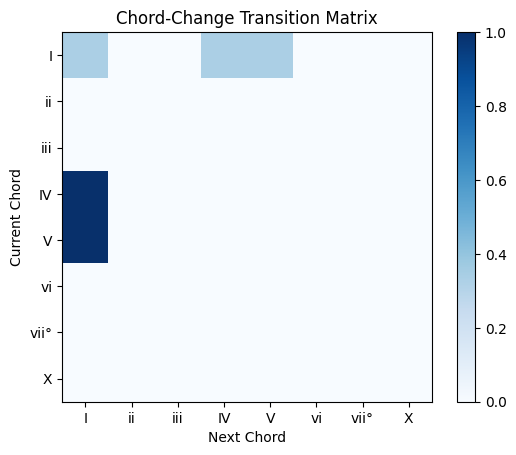

In [ ]:
def steady_state_vec(matrix):
    matrix = matrix.T  # Transpose to get correct orientation for Markov chain
    dim = matrix.shape[0]
    q = (matrix - np.eye(dim))
    ones = np.ones(dim)
    q = np.c_[q, ones]
    QTQ = np.dot(q, q.T)
    bQT = np.ones(dim)

    return np.linalg.solve(QTQ, bQT)

example = markov_matrices["Major"][300]

labels = ['I', 'ii', 'iii', 'IV', 'V', 'vi', 'vii°', '*']

plt.imshow(example, cmap='Blues')
plt.colorbar()
plt.title("Chord-Change Transition Matrix")
plt.xlabel("Next Chord")
plt.ylabel("Current Chord")
plt.yticks(ticks=np.arange(8), labels=labels)
plt.xticks(ticks=np.arange(8), labels=labels)


example = steady_state_vec(example)  # Example: first Major matrix
print("Steady-state distribution of chords:")
for label, prob in zip(labels, example):
    print(f"{label}: {prob:.4f}")

In [ ]:
from scipy.optimize import minimize

# ── Inner Simplex Algorithm (ISA) ─────────────────────────────────────────────
def _isa(X, m):
    """
    Find m rows of X that best represent the vertices of the data simplex.
    Uses sequential Gram-Schmidt orthogonalisation to locate extremal points.
    """
    B = X.copy().astype(float)
    vertices = [int(np.argmax(np.linalg.norm(B, axis=1)))]
    for _ in range(1, m):
        v = B[vertices[-1]].copy()
        norm = np.linalg.norm(v)
        if norm > 1e-12:
            v /= norm
            B -= np.outer(B @ v, v)
        norms = np.linalg.norm(B, axis=1)
        for vi in vertices:
            norms[vi] = -np.inf
        vertices.append(int(np.argmax(norms)))
    return vertices


# ── PCCA+ ─────────────────────────────────────────────────────────────────────
def pcca_plus(P, m):
    """
    PCCA+ spectral clustering algorithm (arXiv:2206.14537).

    Finds m metastable clusters of the n states of a row-stochastic Markov
    chain by computing a fuzzy membership matrix χ = X·A, where X contains
    the m dominant right eigenvectors of P and A is optimised for crispness.

    Args:
        P : (n, n) row-stochastic transition matrix
        m : number of metastable clusters

    Returns:
        chi : (n, m) membership matrix  - rows sum to 1, values in [0, 1]
        A   : (m, m) optimal transformation matrix
    """
    n = P.shape[0]
    assert 1 < m <= n, "m must satisfy 1 < m ≤ n"

    # ── Step 1: m dominant right eigenvectors of P ───────────────────────────
    eigenvalues, eigenvectors = np.linalg.eig(P)
    order = np.argsort(eigenvalues.real)[::-1]          # descending |λ|
    X = eigenvectors[:, order[:m]].real                 # (n, m)

    # ── Step 2: ISA – initial transformation from simplex vertices ───────────
    vertices = _isa(X, m)
    S  = X[vertices, :]          # (m, m) vertex submatrix
    A0 = np.linalg.inv(S)        # initial A

    # ── Step 3: Maximise crispness  Σᵢⱼ χᵢⱼ²  (= minimise –Σ χ²) ──────────
    #   subject to  χ = X·A ∈ [0,1]  and  χ·1 = 1  (via penalty terms)
    def neg_crispness(a_flat):
        A   = a_flat.reshape(m, m)
        chi = X @ A
        obj = -np.sum(chi ** 2)
        pen = 1e4 * (
            np.sum(np.maximum(0.0, -chi) ** 2) +          # chi ≥ 0
            np.sum(np.maximum(0.0,  chi - 1.0) ** 2) +   # chi ≤ 1
            np.sum((chi.sum(axis=1) - 1.0) ** 2)          # rows sum to 1
        )
        return obj + pen

    result = minimize(
        neg_crispness, A0.flatten(), method="Nelder-Mead",
        options={"maxiter": 100_000, "xatol": 1e-10, "fatol": 1e-10, "adaptive": True},
    )
    A_opt = result.x.reshape(m, m)

    # ── Step 4: Build and normalise membership matrix ────────────────────────
    chi = X @ A_opt
    chi = np.clip(chi, 0.0, 1.0)
    chi /= chi.sum(axis=1, keepdims=True)

    return chi, A_opt

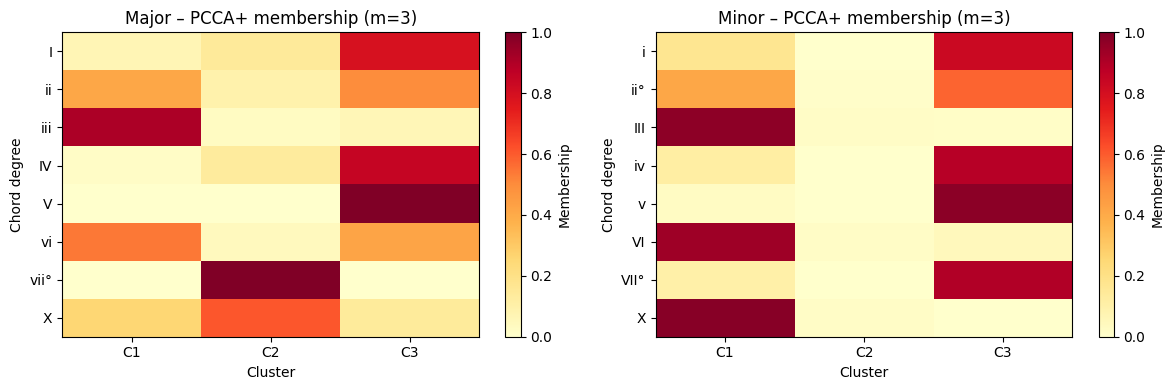

In [129]:
# Apply PCCA+ to the mean transition matrix for each mode
# m = number of metastable chord clusters to find
M = 3

chord_labels = {
    "Major": ["I", "ii", "iii", "IV", "V", "vi", "vii°", "X"],
    "Minor": ["i", "ii°", "III", "iv", "v", "VI", "VII°", "X"],
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, mode in zip(axes, ["Major", "Minor"]):
    matrices = np.array([v["matrix"] for v in markov_matrices[mode].values()])
    mean_P   = matrices.mean(axis=0)          # average transition matrix

    chi, _ = pcca_plus(mean_P, M)

    im = ax.imshow(chi, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
    fig.colorbar(im, ax=ax, label="Membership")
    ax.set_title(f"{mode} – PCCA+ membership (m={M})")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Chord degree")
    ax.set_xticks(range(M),      [f"C{i+1}" for i in range(M)])
    ax.set_yticks(range(8),      chord_labels[mode])

plt.tight_layout()
plt.show()